First 5 Rows
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      

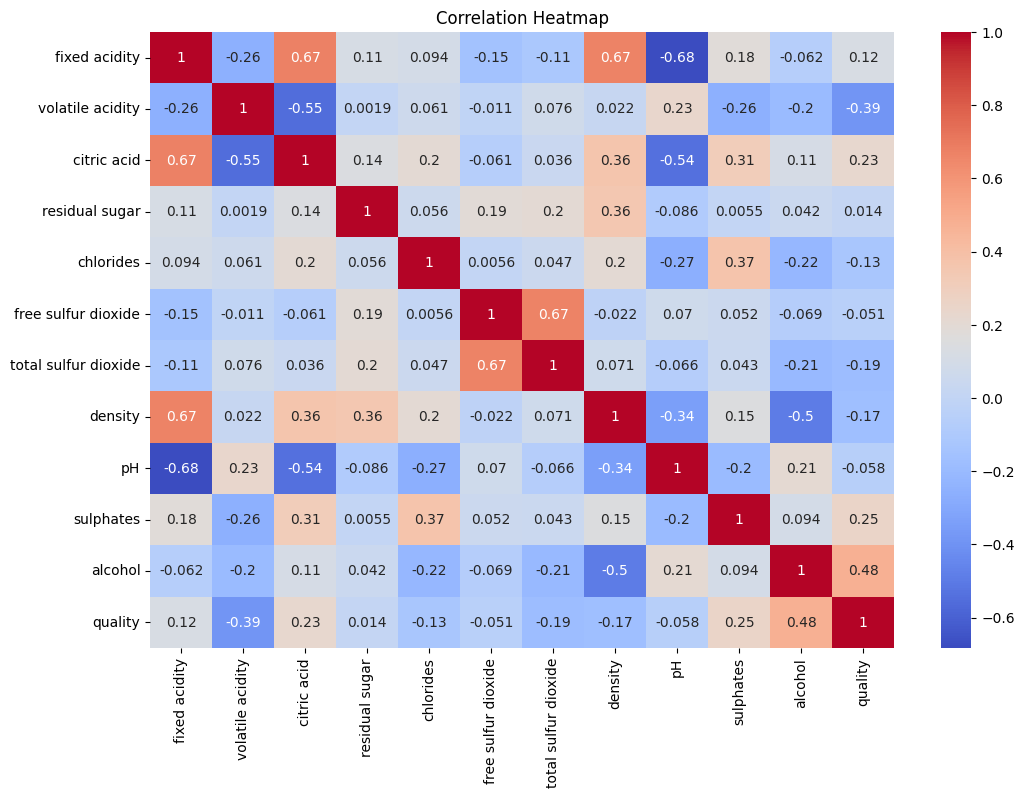


Correlation with Quality
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

Class Distribution
quality_label
0    1382
1     217
Name: count, dtype: int64


LOGISTIC REGRESSION WITHOUT SCALING
Accuracy : 0.89375
Precision: 0.7368421052631579
Recall   : 0.32558139534883723
F1 Score : 0.45161290322580644

Confusion Matrix
[[272   5]
 [ 29  14]]


LOGISTIC REGRESSION WITH SCALING
Accuracy : 0.89375
Precision: 0.6956521739130435
Recall   : 0.37209302325581395
F1 Score : 0.48484848484848486

Confusion Matrix
[[270   7]
 [ 27  16]]


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logis

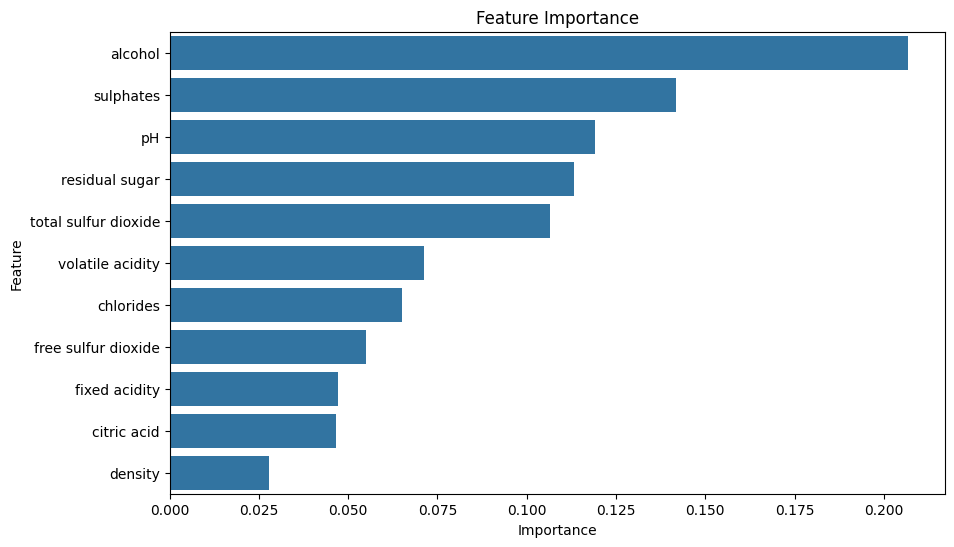


Project Completed Successfully!


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



df = pd.read_csv('winequality.csv')


print("First 5 Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())



plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with Quality")
print(df.corr()['quality'].sort_values(ascending=False))


df['quality_label'] = (df['quality'] >= 7).astype(int)

print("\nClass Distribution")
print(df['quality_label'].value_counts())



X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\n")
print("="*50)
print("LOGISTIC REGRESSION WITHOUT SCALING")
print("="*50)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("\n")
print("="*50)
print("LOGISTIC REGRESSION WITH SCALING")
print("="*50)

lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall   :", recall_score(y_test, y_pred_scaled))
print("F1 Score :", f1_score(y_test, y_pred_scaled))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_scaled))



print("\n")
print("="*50)
print("MODEL COMPARISON")
print("="*50)

# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# KNN

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

# Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, dt_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, dt_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, dt_pred)
    ]
})

print(results)



best_model_name = results.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]['Model']

print("\nBest Model:", best_model_name)



print("\n")
print("="*50)
print("GRID SEARCH CV")
print("="*50)

param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_knn = grid.best_estimator_

final_pred = best_knn.predict(X_test_scaled)

print("\nFinal Model Performance")

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

print("\nClassification Report")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, final_pred))



print("\n")
print("="*50)
print("FEATURE IMPORTANCE")
print("="*50)

feature_model = DecisionTreeClassifier(
    random_state=42
)

feature_model.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance")
plt.show()



print("\nProject Completed Successfully!")